# Trial conversion model: exploration

This notebook is the exploration companion to the `trial_conversion_model` package. The pipeline itself lives in the package: `trial_conversion_model.data` loads the raw extract, `trial_conversion_model.features` derives the model features and writes the processed training table, `trial_conversion_model.train` trains and saves the model, and `uv run scripts/train.py` runs the whole thing from the command line. This notebook only imports those pieces to look at the data behind the model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from trial_conversion_model.data import load_raw
from trial_conversion_model.features import add_features

df = add_features(load_raw(Path("../data/01_raw/trial_snapshot.csv")))
print(df.shape)
print("conversion rate:", df["converted"].mean().round(4))

(1516, 17)
conversion rate: 0.5323


In [2]:
df.groupby("converted")[
    ["sessions_3d", "active_days_3d", "total_minutes_3d"]
].mean().round(2)

,sessions_3d,active_days_3d,total_minutes_3d
converted,,,
0,7.29,2.07,76.78
1,11.74,2.81,125.66


In [3]:
# steady users vs binge tourists: same totals, very different outcomes
binge = (df["day1_share"] > 0.6) & (df["sessions_3d"] >= 3)
df.groupby(binge)["converted"].agg(["mean", "count"])

,mean,count
False,0.620601,1165
True,0.239316,351


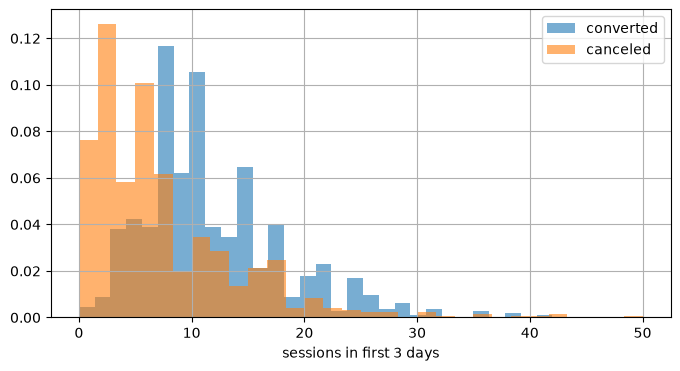

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df.converted == 1]["sessions_3d"].hist(
    bins=30, alpha=0.6, label="converted", ax=ax, density=True
)
df[df.converted == 0]["sessions_3d"].hist(
    bins=30, alpha=0.6, label="canceled", ax=ax, density=True
)
ax.set_xlabel("sessions in first 3 days")
ax.legend()
plt.show()

To rebuild the training table and retrain the model after changing anything in the package, run `uv run scripts/train.py` from the project root. The processed table lands in `data/03_processed/` and the trained model and its metrics land in `models/`.